# Final project notebook
---
Covers q1 and q2

In [51]:
from bdt_numpy import calibrate_bdt, price_bonds_at_nodes, backward_induction_no_discount, price_bonds_on_tree, futures_delivery_option, futures_delivery_option_tree

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import time

In [52]:
cap_curves = pd.read_excel('data/cap_curves_2026-02-27.xlsx', sheet_name=None)
fut_bond_USM6 = pd.read_excel('data/fut_bond_data_USM6_2026-03-02.xlsx', sheet_name=None)
gsw_data = pd.read_excel('data/gsw_params_2026-02-27.xlsx', sheet_name=None)

futures_info = fut_bond_USM6['future'].set_index('field')['USM6 Comdty']
bonds = fut_bond_USM6['bonds'].copy()
daily = fut_bond_USM6['daily'].copy()

gsw_params = gsw_data['svensson_params'].set_index('parameter')['value']
gsw_weekly = gsw_data['zero_yields_weekly'].copy()

fut_price_market = float(futures_info['px_last'])
delivery_date = pd.Timestamp(futures_info['last_tradeable_dt'])

print(f"Futures price: {fut_price_market}")
print(f"Last trading date: {delivery_date.date()}")
print(f"Bloomberg CTD: {futures_info['fut_ctd']}")
print(f"Number of deliverable bonds: {len(bonds)}")

Futures price: 117.5625
Last trading date: 2026-06-18
Bloomberg CTD: T 4.75 11/15/43
Number of deliverable bonds: 59


In [53]:
def svensson(tau, beta0, beta1, beta2, beta3, tau1, tau2):
    """Svensson yield curve formula. Returns yield in same units as betas (percent)."""
    tau = np.asarray(tau, dtype=float)
    x1 = tau / tau1
    x2 = tau / tau2
    term1 = beta1 * (1 - np.exp(-x1)) / x1
    term2 = beta2 * ((1 - np.exp(-x1)) / x1 - np.exp(-x1))
    term3 = beta3 * ((1 - np.exp(-x2)) / x2 - np.exp(-x2))
    return beta0 + term1 + term2 + term3

def price_bond_textbook(ytm, T, cpn, cpnfreq=2, face=100):
    """Price given annual YTM, years to maturity T, annual coupon cpn (decimal), coupon frequency."""
    ytm_n = ytm / cpnfreq
    cpn_n = cpn / cpnfreq
    N = T * cpnfreq
    price = face * ((cpn_n / ytm_n) * (1 - (1 + ytm_n)**(-N)) + (1 + ytm_n)**(-N))
    return price

## Question 1: Deliverable Basket and CTD Switching

### 1a) Adjusted Clean Prices and CTD Identification

In [54]:
bonds['adj_price'] = bonds['px_mid'] / bonds['conversion']

# Sort by adjusted price to find CTD
bonds_sorted = bonds.sort_values('adj_price').reset_index(drop=True)

ctd_bond = bonds_sorted.iloc[0]
print(f"Current CTD (by adjusted price): {ctd_bond['security_des']}")
print(f"  Adjusted price: {ctd_bond['adj_price']:.4f}")
print(f"  Bloomberg CTD: {futures_info['fut_ctd']}")
print(f"\nNote: Bloomberg uses implied repo rate for CTD identification, not adjusted price.")

# Top-15 table
top15 = bonds_sorted.head(15)[['security_des', 'cpn', 'maturity', 'conversion', 
                                 'dur_adj_mid', 'adj_price']].copy()
top15.columns = ['Security', 'Coupon', 'Maturity', 'Conv Factor', 'Duration', 'Adj Price']
top15['Maturity'] = top15['Maturity'].dt.strftime('%Y-%m-%d')
top15.index = range(1, 16)
top15.index.name = 'Rank'
display(top15)

Current CTD (by adjusted price): T 4 3/8 08/15/43
  Adjusted price: 117.9185
  Bloomberg CTD: T 4.75 11/15/43

Note: Bloomberg uses implied repo rate for CTD identification, not adjusted price.


,Security,Coupon,Maturity,Conv Factor,Duration,Adj Price
Rank,,,,,,
1,T 4 3/8 08/15/43,4.375,2043-08-15,0.8283,12.017231,117.918478
2,T 4 3/4 11/15/43,4.750,2043-11-15,0.8667,11.797196,117.922147
3,T 4 11/15/42,4.000,2042-11-15,0.7941,11.752172,117.940121
4,T 4 1/2 02/15/44,4.500,2044-02-15,0.8388,12.167274,117.979182
5,T 4 5/8 05/15/44,4.625,2044-05-15,0.8510,12.066154,117.995373
6,T 3 7/8 02/15/43,3.875,2043-02-15,0.7794,12.068106,118.019470
7,T 3 3/4 11/15/43,3.750,2043-11-15,0.7602,12.352237,118.019929
8,T 3 5/8 08/15/43,3.625,2043-08-15,0.7491,12.449053,118.037478
9,T 4 5/8 11/15/44,4.625,2044-11-15,0.8487,12.268041,118.057397


### 1b) Repricing Under Parallel Yield Shifts

At 0bp shift — Market vs Model adjusted price (top 5 by market):
  T 4 3/8 08/15/43           market=117.918  model=119.244  diff=1.326
  T 4 3/4 11/15/43           market=117.922  model=119.173  diff=1.251
  T 4 11/15/42               market=117.940  model=119.184  diff=1.243
  T 4 1/2 02/15/44           market=117.979  model=119.309  diff=1.330
  T 4 5/8 05/15/44           market=117.995  model=119.318  diff=1.323


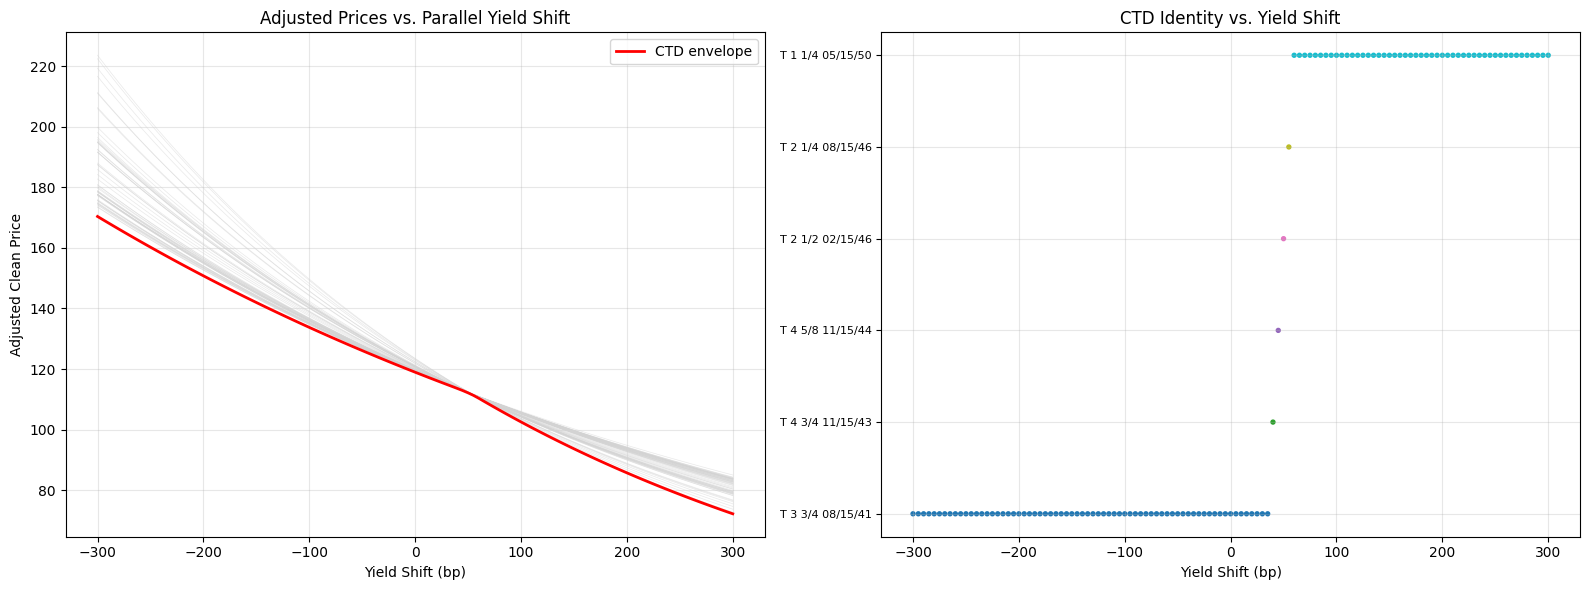

In [55]:
# GSW zero yields (cc, in percent) at weekly tenors
tenors = gsw_weekly['tenor_years'].values
base_yields_pct = gsw_weekly['zero_yield_cc_pct'].values  # in percent

# Bond characteristics
settle_date = pd.Timestamp('2026-03-02')
coupons = bonds['cpn'].values / 100  # decimal
maturities = pd.to_datetime(bonds['maturity'])
conv_factors = bonds['conversion'].values
accrued_interest = bonds['int_acc'].values  # AI doesn't change with yield shifts
n_bonds = len(bonds)

def reprice_bonds_spot(shift_bps):
    """Reprice all bonds using shifted GSW spot curve. Returns clean prices."""
    shift_pct = shift_bps / 100  # convert bp to percent
    shifted_yields_dec = (base_yields_pct + shift_pct) / 100  # decimal
    
    dirty_prices = np.zeros(n_bonds)
    for j in range(n_bonds):
        cpn_rate = coupons[j]
        mat = maturities.iloc[j]
        cpn_payment = 100 * cpn_rate / 2
        
        # Generate semi-annual coupon dates backward from maturity
        cpn_dates = []
        d = mat
        while d > settle_date:
            cpn_dates.append(d)
            d = d - pd.DateOffset(months=6)
        cpn_dates = sorted(cpn_dates)
        
        # Time from settlement to each cash flow (in years)
        cf_times = np.array([(d - settle_date).days / 365.25 for d in cpn_dates])
        cf_amounts = np.full(len(cf_times), cpn_payment)
        cf_amounts[-1] += 100  # principal at maturity
        
        # Interpolate shifted spot rates at cf_times
        spot_rates = np.interp(cf_times, tenors, shifted_yields_dec)
        
        # Discount: D = exp(-y * t) for cc rates
        disc_factors = np.exp(-spot_rates * cf_times)
        dirty_prices[j] = np.sum(cf_amounts * disc_factors)
    
    # Clean = dirty - accrued interest (AI is fixed, independent of yields)
    return dirty_prices - accrued_interest

# Parallel shifts: ±300bp in 5bp increments
shifts = np.arange(-300, 301, 5)
adj_prices_shifted = np.zeros((len(shifts), n_bonds))

for i, s in enumerate(shifts):
    clean_prices = reprice_bonds_spot(s)
    adj_prices_shifted[i, :] = clean_prices / conv_factors

market_adj = bonds['px_mid'].values / conv_factors
model_adj_0 = adj_prices_shifted[shifts == 0].flatten()
print("At 0bp shift — Market vs Model adjusted price (top 5 by market):")
order = np.argsort(market_adj)[:5]
for idx in order:
    print(f"  {bonds.iloc[idx]['security_des']:25s}  market={market_adj[idx]:.3f}  model={model_adj_0[idx]:.3f}  diff={model_adj_0[idx]-market_adj[idx]:.3f}")

# CTD at each shift = bond with lowest adjusted price
ctd_idx_by_shift = np.argmin(adj_prices_shifted, axis=1)
ctd_envelope = np.min(adj_prices_shifted, axis=1)

# Plot 1: All adjusted prices vs yield shift, CTD envelope highlighted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for j in range(n_bonds):
    ax.plot(shifts, adj_prices_shifted[:, j], color='lightgray', alpha=0.5, linewidth=0.5)
ax.plot(shifts, ctd_envelope, color='red', linewidth=2, label='CTD envelope')
ax.set_xlabel('Yield Shift (bp)')
ax.set_ylabel('Adjusted Clean Price')
ax.set_title('Adjusted Prices vs. Parallel Yield Shift')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: CTD identity vs yield shift
ax = axes[1]
ctd_names = [bonds.iloc[idx]['security_des'] for idx in ctd_idx_by_shift]
unique_ctd = list(dict.fromkeys(ctd_names))  # preserve order
ctd_num = [unique_ctd.index(n) for n in ctd_names]

ax.scatter(shifts, ctd_num, c=ctd_num, cmap='tab10', s=8)
ax.set_yticks(range(len(unique_ctd)))
ax.set_yticklabels(unique_ctd, fontsize=8)
ax.set_xlabel('Yield Shift (bp)')
ax.set_title('CTD Identity vs. Yield Shift')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1c) CTD Switching Points

In [56]:
switching_points = []
for i in range(1, len(shifts)):
    if ctd_idx_by_shift[i] != ctd_idx_by_shift[i-1]:
        switching_points.append({
            'shift_bp': shifts[i],
            'from': bonds.iloc[ctd_idx_by_shift[i-1]]['security_des'],
            'to': bonds.iloc[ctd_idx_by_shift[i]]['security_des'],
            'from_dur': bonds.iloc[ctd_idx_by_shift[i-1]]['dur_adj_mid'],
            'to_dur': bonds.iloc[ctd_idx_by_shift[i]]['dur_adj_mid'],
        })

n_distinct = len(set(ctd_idx_by_shift))
print(f"Number of distinct CTD bonds across ±300bp: {n_distinct}")
print(f"Number of switching points: {len(switching_points)}\n")

switch_df = pd.DataFrame(switching_points)
display(switch_df)

Number of distinct CTD bonds across ±300bp: 6
Number of switching points: 5



,shift_bp,from,to,from_dur,to_dur
0,40,T 3 3/4 08/15/41,T 4 3/4 11/15/43,11.414505,11.797196
1,45,T 4 3/4 11/15/43,T 4 5/8 11/15/44,11.797196,12.268041
2,50,T 4 5/8 11/15/44,T 2 1/2 02/15/46,12.268041,14.549255
3,55,T 2 1/2 02/15/46,T 2 1/4 08/15/46,14.549255,15.073294
4,60,T 2 1/4 08/15/46,T 1 1/4 05/15/50,15.073294,18.551258


The basket spans durations 11.4–18.6 years. 
CTD switches occur as yields rise — transitioning from low-duration to progressively 
higher-duration bonds. This reflects the conversion factor system's 6% calibration:

- Below 6%: low-duration bonds are cheapest to deliver (their prices are least 
  inflated above CF×100, since they have less interest-rate sensitivity)
- As yields rise toward 6%: all adjusted prices converge toward 100
- Above 6%: high-duration bonds become CTD (their prices fall furthest below CF×100)

Despite having 59 deliverables, switching is concentrated in a narrow yield range 
because at current yields (~4–4.5%) the lowest-duration bond dominates across most 
of the negative-shift region, and switches happen only as yields rise enough to 
favor longer-duration bonds.

### 1d) Current CTD Characteristics

In [57]:
ctd_at_zero = bonds.iloc[ctd_idx_by_shift[shifts == 0][0]]
dur_range = bonds['dur_adj_mid']

print(f"Current CTD (model): {ctd_at_zero['security_des']}")
print(f"  Duration: {ctd_at_zero['dur_adj_mid']:.2f} years")
print(f"  Coupon: {ctd_at_zero['cpn']:.3f}%")
print(f"  Basket duration range: {dur_range.min():.1f} – {dur_range.max():.1f} years")
print(f"  Basket median duration: {dur_range.median():.1f} years")

is_high_dur = ctd_at_zero['dur_adj_mid'] > dur_range.median()
print(f"\nThe CTD is {'HIGH' if is_high_dur else 'LOW'} duration relative to the basket.")

Current CTD (model): T 3 3/4 08/15/41
  Duration: 11.41 years
  Coupon: 3.750%
  Basket duration range: 11.4 – 18.6 years
  Basket median duration: 12.8 years

The CTD is LOW duration relative to the basket.


At current yields (~4–4.5%), well below the 6% notional coupon used to compute 
conversion factors, the CTD is a low-duration bond. This is the standard duration 
bias of the CF system:

1. The CF equals each bond's price at a flat 6% yield (÷ 100). At market yields 
   below 6%, all bonds trade above CF×100. But high-duration bonds overshoot more 
   (greater price sensitivity), so their adjusted price (= clean / CF) is higher.

2. Low-duration bonds are least "inflated" relative to their CF, making them 
   cheapest to deliver. The adjusted-price curves in 1b confirm this: at zero 
   shift, the flattest (lowest-duration) curve sits at the bottom of the envelope.

3. The convexity of the adjusted price curves also matters: the CTD envelope is 
   the lower hull — a concave function of yield shift. Near the current yield, 
   the CTD sits at the "vertex" of this hull, with switching points on either side.
   Since yields are well below 6%, we are far from the crossover region, and the 
   low-duration bond dominates over a wide range of negative shifts.

## Question 2: Rate Tree Construction and Calibration

### 2a) Svensson Yield Curve and BDT Calibration

In [58]:
b0, b1, b2, b3 = gsw_params['BETA0'], gsw_params['BETA1'], gsw_params['BETA2'], gsw_params['BETA3']
t1, t2 = gsw_params['TAU1'], gsw_params['TAU2']

# Use pre-computed weekly data for discounts
dt = 1/52
tenors_weekly = gsw_weekly['tenor_years'].values
discounts_weekly = gsw_weekly['discount_factor'].values

# Verify Svensson reproduces provided yields
y_check = svensson(tenors_weekly, b0, b1, b2, b3, t1, t2)
print(f"Svensson yield check (first 5): {y_check[:5]}")
print(f"Provided yields (first 5):      {gsw_weekly['zero_yield_cc_pct'].values[:5]}")

# Flat vol from cap curve (0.5Y tenor)
cap_df = cap_curves[list(cap_curves.keys())[0]]
flat_vol = cap_df.loc[cap_df['tenor'] == 0.5, 'flat vols'].values[0]
print(f"\nFlat vol (from cap curve, 0.5Y): {flat_vol:.6f} = {flat_vol*100:.2f}%")

# Number of weekly steps = number of discount factors
n_steps = len(discounts_weekly)
print(f"Tree depth: {n_steps} weekly steps ({n_steps/52:.1f} years)")

# Calibrate BDT tree
t0 = time.time()
rate_tree, z_top, ad_prices = calibrate_bdt(discounts_weekly, flat_vol, dt)
elapsed = time.time() - t0

print(f"\nCalibration time: {elapsed:.2f} seconds")
print(f"Rate tree shape: {rate_tree.shape}")
print(f"Arrow-Debreu prices shape: {ad_prices.shape}")

# Delivery step: ceil to ensure we span the full delivery horizon
import math
n_delivery = math.ceil((delivery_date - settle_date).days / 7)
print(f"\nDelivery step (n_delivery): {n_delivery}")
print(f"Terminal states at delivery: {n_delivery + 1}")

Svensson yield check (first 5): [3.77919842 3.77103047 3.76297676 3.75503609 3.74720726]
Provided yields (first 5):      [3.77919842 3.77103047 3.76297676 3.75503609 3.74720726]

Flat vol (from cap curve, 0.5Y): 0.111096 = 11.11%
Tree depth: 1560 weekly steps (30.0 years)

Calibration time: 0.82 seconds
Rate tree shape: (1561, 1561)
Arrow-Debreu prices shape: (1561, 1561)

Delivery step (n_delivery): 16
Terminal states at delivery: 17


### 2b) Zero-Coupon Bond Repricing via Arrow-Debreu Prices

In [59]:
n_steps = len(discounts_weekly)
zcb_ad_prices = np.zeros(n_steps)

for k in range(n_steps):
    states = np.arange(k + 1)
    ad_col = ad_prices[:k+1, k]
    rates_col = rate_tree[:k+1, k]
    zcb_ad_prices[k] = np.sum(ad_col * np.exp(-rates_col * dt))

pricing_errors = zcb_ad_prices - discounts_weekly
max_error = np.max(np.abs(pricing_errors))

print(f"Maximum absolute ZCB pricing error: {max_error:.2e}")
print(f"Mean absolute error: {np.mean(np.abs(pricing_errors)):.2e}")
print(f"\nAD calibration is exact: error < 1e-12? {'Yes' if max_error < 1e-12 else 'No (but very small)'}")

# Show sample points
print(f"\n{'Step':>5} {'Tenor':>8} {'D(market)':>12} {'D(AD)':>12} {'Error':>14}")
for k in [0, 1, 2, 51, 103, 259, 519, n_steps-1]:
    if k < n_steps:
        print(f"{k+1:5d} {tenors_weekly[k]:8.4f} {discounts_weekly[k]:12.8f} {zcb_ad_prices[k]:12.8f} {pricing_errors[k]:14.2e}")

Maximum absolute ZCB pricing error: 2.22e-16
Mean absolute error: 2.29e-17

AD calibration is exact: error < 1e-12? Yes

 Step    Tenor    D(market)        D(AD)          Error
    1   0.0192   0.99927350   0.99927350       0.00e+00
    2   0.0385   0.99855065   0.99855065       0.00e+00
    3   0.0577   0.99783141   0.99783141       0.00e+00
   52   1.0000   0.96573888   0.96573888       0.00e+00
  104   2.0000   0.93478878   0.93478878      -1.11e-16
  260   5.0000   0.83920633   0.83920633       0.00e+00
  520  10.0000   0.66735129   0.66735129       0.00e+00
 1560  30.0000   0.23360350   0.23360350       2.78e-17


### 2c) Rate Tree Heatmap and Terminal Rate Distribution

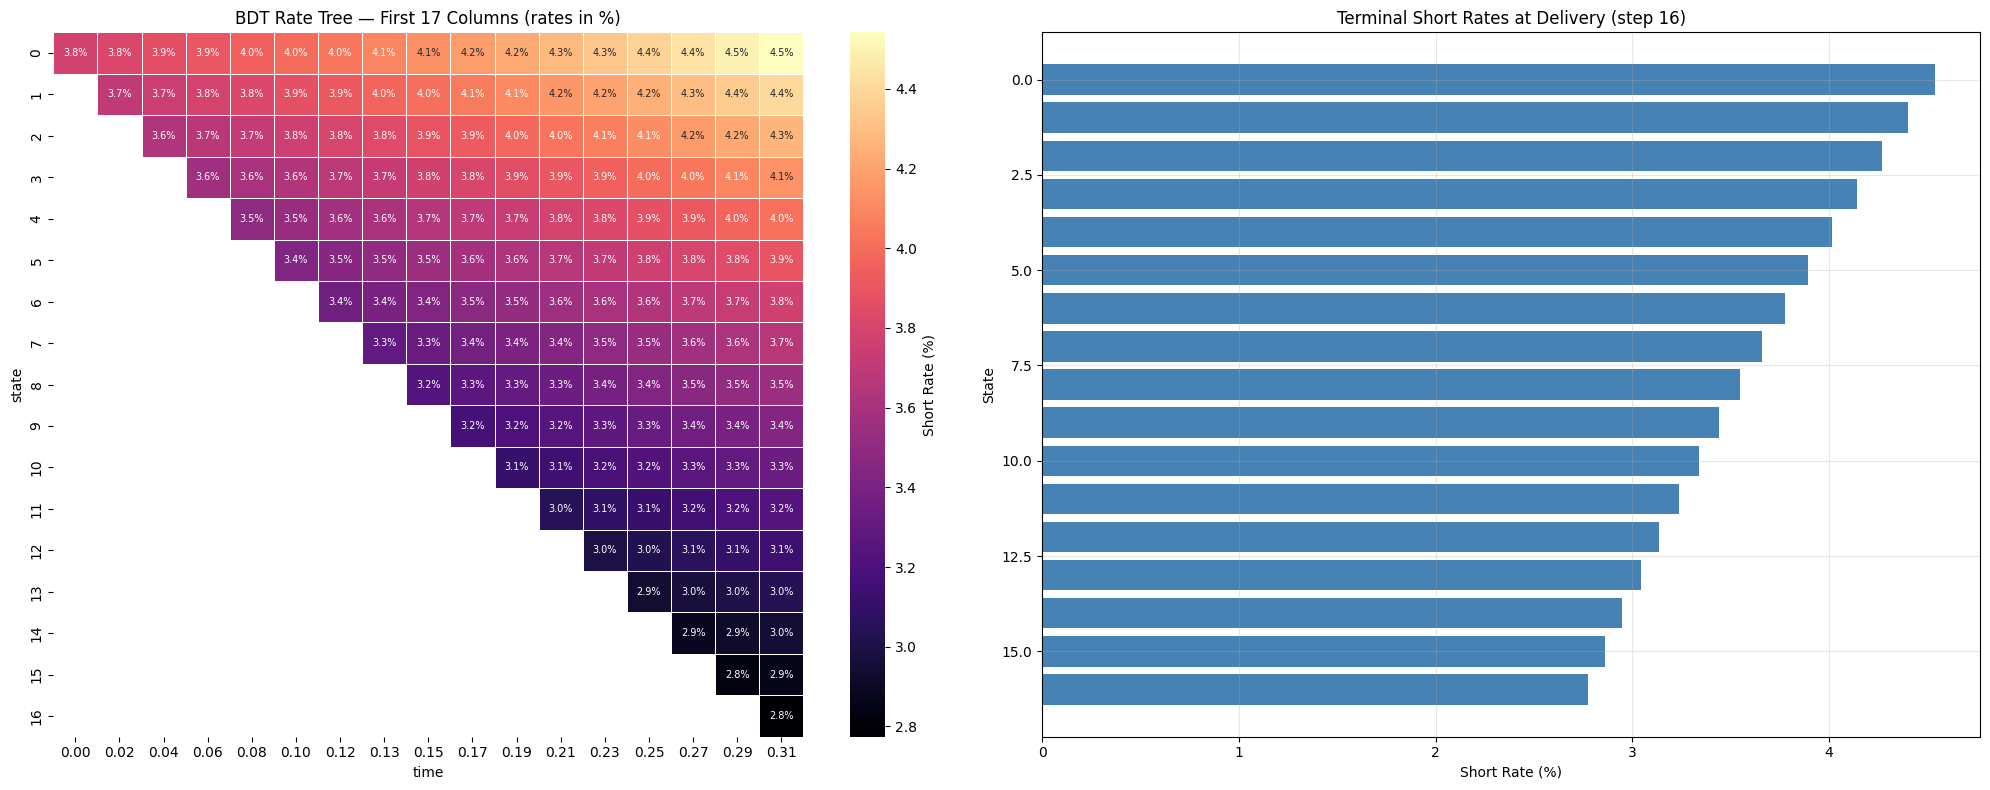

Terminal short rate range: 2.7742% – 4.5420%
Number of terminal states: 17


In [60]:
# Hard fix
S = n_delivery + 1  # 17 terminal states

# Build DataFrame for seaborn heatmap
# Columns = time steps (in years), rows = states
time_labels = [f"{k * dt:.2f}" for k in range(S)]
rate_slice = rate_tree[:S, :S].copy() * 100  # percent

# Replace NaN with np.nan for seaborn masking
rate_df = pd.DataFrame(rate_slice, 
                        index=range(S),
                        columns=time_labels)

# Format annotations: show as "X.X%" 
annot = np.full_like(rate_slice, '', dtype=object)
for i in range(S):
    for j in range(S):
        if not np.isnan(rate_slice[i, j]):
            annot[i, j] = f"{rate_slice[i, j]:.1f}%"

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap with seaborn
ax = axes[0]
sns.heatmap(rate_df, ax=ax, annot=annot, fmt='', cmap='magma',
            mask=np.isnan(rate_slice), linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Short Rate (%)'},
            annot_kws={'size': 7})
ax.set_xlabel('time')
ax.set_ylabel('state')
ax.set_title(f'BDT Rate Tree — First {S} Columns (rates in %)')

# Histogram of terminal short rates
terminal_rates = rate_tree[:S, n_delivery] * 100  # percent
ax = axes[1]
ax.barh(range(S), terminal_rates, color='steelblue')
ax.set_ylabel('State')
ax.set_xlabel('Short Rate (%)')
ax.set_title(f'Terminal Short Rates at Delivery (step {n_delivery})')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Terminal short rate range: {terminal_rates.min():.4f}% – {terminal_rates.max():.4f}%")
print(f"Number of terminal states: {S}")

### 2d) Assessment: Do Terminal States Capture CTD Switching?

In [61]:
# Approximate: use flat yield = terminal short rate as proxy for bond pricing
terminal_rates_dec = rate_tree[:S, n_delivery]  # cc rates in decimal

delivery_dt = delivery_date
T_rem = np.array([(pd.Timestamp(m) - delivery_dt).days / 365.25 for m in bonds['maturity']])
cpn_arr = bonds['cpn'].values / 100
cf_arr = bonds['conversion'].values

accr_frac = np.zeros(n_bonds)
_, clean_approx = price_bonds_at_nodes(terminal_rates_dec, cpn_arr, T_rem, 2, 100, accr_frac)
adj_approx = clean_approx / cf_arr[None, :]
ctd_by_state = np.argmin(adj_approx, axis=1)

n_distinct_ctd = len(set(ctd_by_state))
ctd_names_tree = [bonds.iloc[idx]['security_des'] for idx in ctd_by_state]

print(f"Terminal rate range: {terminal_rates.min():.2f}% – {terminal_rates.max():.2f}%")
print(f"Distinct CTD bonds across {S} terminal states (flat-yield proxy): {n_distinct_ctd}")
print(f"\nCTD by state:")
for i in range(S):
    marker = " <-- median" if i == S // 2 else ""
    print(f"  State {i:2d}: r={terminal_rates[i]:.2f}%  CTD={ctd_names_tree[i]}{marker}")

Terminal rate range: 2.77% – 4.54%
Distinct CTD bonds across 17 terminal states (flat-yield proxy): 1

CTD by state:
  State  0: r=4.54%  CTD=T 3 3/4 08/15/41
  State  1: r=4.40%  CTD=T 3 3/4 08/15/41
  State  2: r=4.27%  CTD=T 3 3/4 08/15/41
  State  3: r=4.14%  CTD=T 3 3/4 08/15/41
  State  4: r=4.02%  CTD=T 3 3/4 08/15/41
  State  5: r=3.89%  CTD=T 3 3/4 08/15/41
  State  6: r=3.78%  CTD=T 3 3/4 08/15/41
  State  7: r=3.66%  CTD=T 3 3/4 08/15/41
  State  8: r=3.55%  CTD=T 3 3/4 08/15/41 <-- median
  State  9: r=3.44%  CTD=T 3 3/4 08/15/41
  State 10: r=3.34%  CTD=T 3 3/4 08/15/41
  State 11: r=3.24%  CTD=T 3 3/4 08/15/41
  State 12: r=3.14%  CTD=T 3 3/4 08/15/41
  State 13: r=3.04%  CTD=T 3 3/4 08/15/41
  State 14: r=2.95%  CTD=T 3 3/4 08/15/41
  State 15: r=2.86%  CTD=T 3 3/4 08/15/41
  State 16: r=2.77%  CTD=T 3 3/4 08/15/41


Using a flat short-rate proxy, only {n_distinct_ctd} distinct CTD bond(s) appear across {S} 
terminal states. This underestimates switching because:

1. Terminal short rates (~{terminal_rates.min():.1f}%–{terminal_rates.max():.1f}%) all lie well below 6%, 
   so the low-duration bond dominates under flat-yield pricing.
   
2. However, terminal short rates ≠ bond YTMs. Each terminal state defines a different 
   term structure extending 15–25 years beyond delivery. The full tree-based backward 
   induction (Q3) will capture how the entire yield curve shape varies across states, 
   which may produce additional CTD transitions not visible in this approximation.
   
3. The Q1 parallel-shift analysis showed switching only at +45–60bp above current 
   yields. The tree's {flat_vol*100:.1f}% vol over {n_delivery} weeks generates a rate 
   range that may not reach those switching thresholds, limiting CTD diversity.
   Q3's full pricing will give the definitive answer.